<a href="https://colab.research.google.com/github/PawanKumar1216/northstar-databases-analytics-assignment/blob/main/notebooks/05_R_Analytics_and_Visualisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 05 R Analytics and Visualisation

## NorthStar Urban Mobility and Logistics

This notebook applies R analytics and visualisation techniques to explore delivery performance, route behaviour, customer complaints, driver ratings, operational costs, customer segments, and relationships between key operational variables within the NorthStar dataset.

## 1. Load Required Libraries and Import Dataset Files from GitHub

The NorthStar operational datasets are imported directly from the project GitHub repository. R packages are used for data manipulation, statistical analysis, and visualisation.

In [1]:
# Install required packages if they are not already available
if (!require("ggplot2")) install.packages("ggplot2", repos = "https://cloud.r-project.org")
if (!require("dplyr")) install.packages("dplyr", repos = "https://cloud.r-project.org")
if (!require("corrplot")) install.packages("corrplot", repos = "https://cloud.r-project.org")

# Load required libraries
library(ggplot2)
library(dplyr)
library(corrplot)

# GitHub raw data URL
base_url <- "https://raw.githubusercontent.com/PawanKumar1216/northstar-databases-analytics-assignment/main/data/"

# Load NorthStar dataset files directly from GitHub
customers <- read.csv(paste0(base_url, "customers.csv"))
deliveries <- read.csv(paste0(base_url, "deliveries.csv"))
complaints <- read.csv(paste0(base_url, "complaints.csv"))
drivers <- read.csv(paste0(base_url, "drivers.csv"))
hubs <- read.csv(paste0(base_url, "hubs.csv"))

print("NorthStar datasets loaded successfully for R analytics.")

Loading required package: ggplot2

Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: corrplot

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘corrplot’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

corrplot 0.95 loaded



[1] "NorthStar datasets loaded successfully for R analytics."


## 2. Delivery Status Distribution Analysis

A bar chart is created to visualise the overall distribution of delivery outcomes across the NorthStar operation. This provides a clear overview of service reliability by comparing on-time, delayed, and failed deliveries.

In [2]:
# Delivery status distribution summary
delivery_status_summary <- deliveries %>%
  count(delivery_status) %>%
  mutate(percentage = round(n / sum(n) * 100, 2))

delivery_status_summary

delivery_status,n,percentage
<chr>,<int>,<dbl>
Delayed,202,21.26
Failed,132,13.89
OnTime,616,64.84


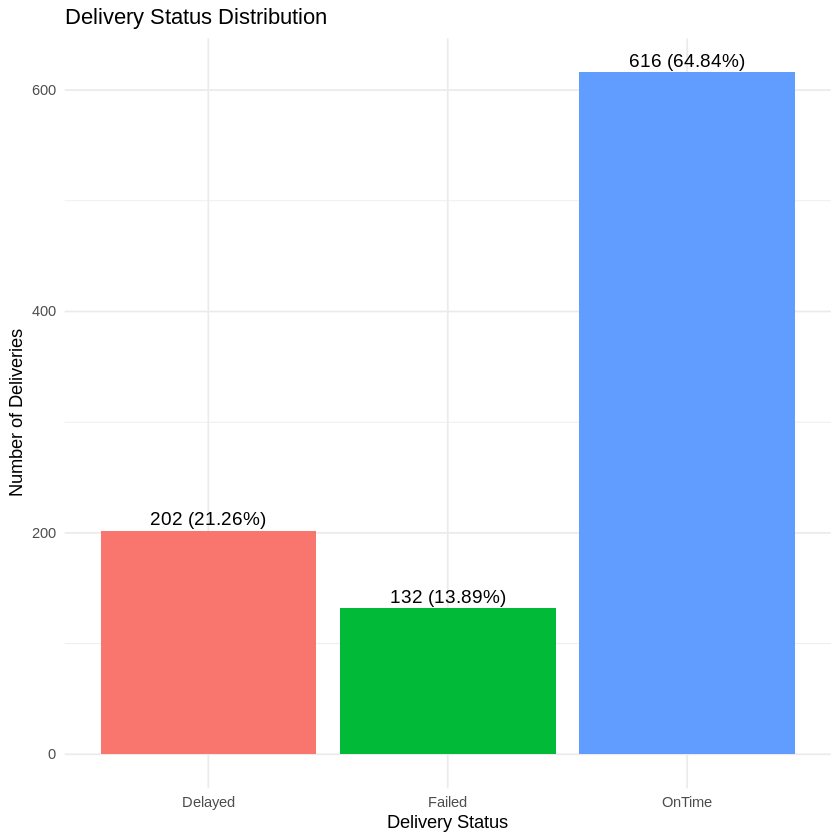

In [3]:
# Bar chart of delivery status distribution
ggplot(delivery_status_summary, aes(x = delivery_status, y = n, fill = delivery_status)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = paste0(n, " (", percentage, "%)")), vjust = -0.4, size = 4) +
  labs(
    title = "Delivery Status Distribution",
    x = "Delivery Status",
    y = "Number of Deliveries"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

## 3. Route Override and Delivery Distance Analysis

A scatter plot is used to examine the relationship between manual route overrides and delivery distance. This helps determine whether deliveries with more route changes are associated with longer journeys and possible routing inefficiencies.

`geom_smooth()` using formula = 'y ~ x'


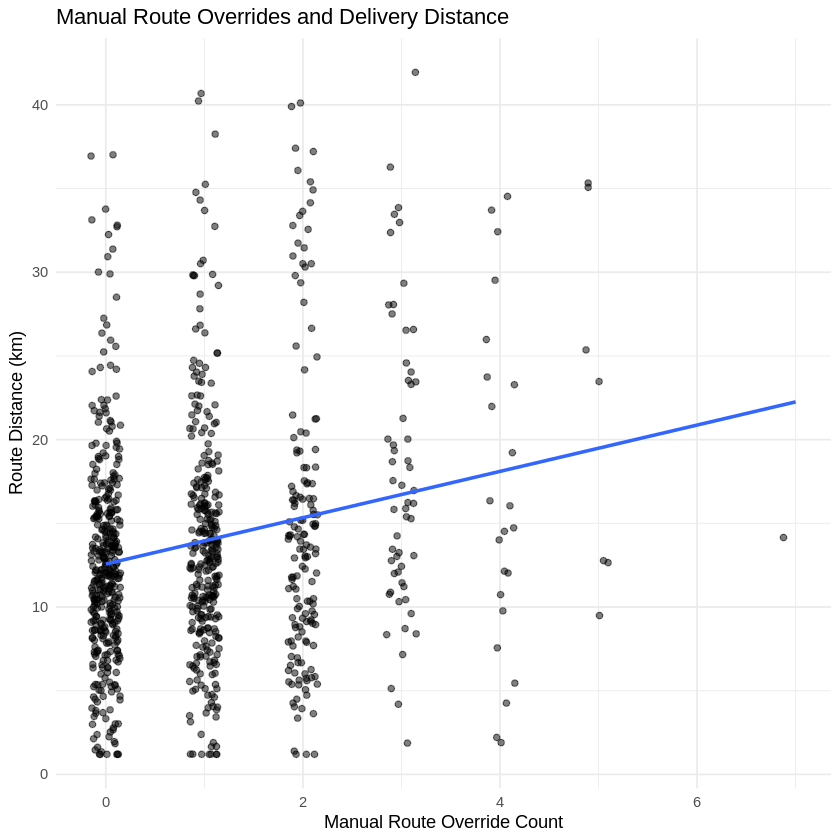

In [4]:
# Scatter plot of manual route overrides against delivery distance
ggplot(deliveries, aes(x = manual_route_override_count, y = route_distance_km)) +
  geom_jitter(width = 0.15, height = 0, alpha = 0.5) +
  geom_smooth(method = "lm", se = FALSE) +
  labs(
    title = "Manual Route Overrides and Delivery Distance",
    x = "Manual Route Override Count",
    y = "Route Distance (km)"
  ) +
  theme_minimal()

## 4. Customer Complaint Severity Analysis

A bar chart is used to examine the distribution of complaint severity levels. This helps identify how many complaints are low, medium, high, or critical and whether serious customer-service issues are present within the operational data.

In [5]:
# Complaint severity distribution
complaint_severity_summary <- complaints %>%
  count(severity) %>%
  mutate(percentage = round(n / sum(n) * 100, 2))

complaint_severity_summary

severity,n,percentage
<chr>,<int>,<dbl>
High,77,24.06
Low,71,22.19
Medium,172,53.75


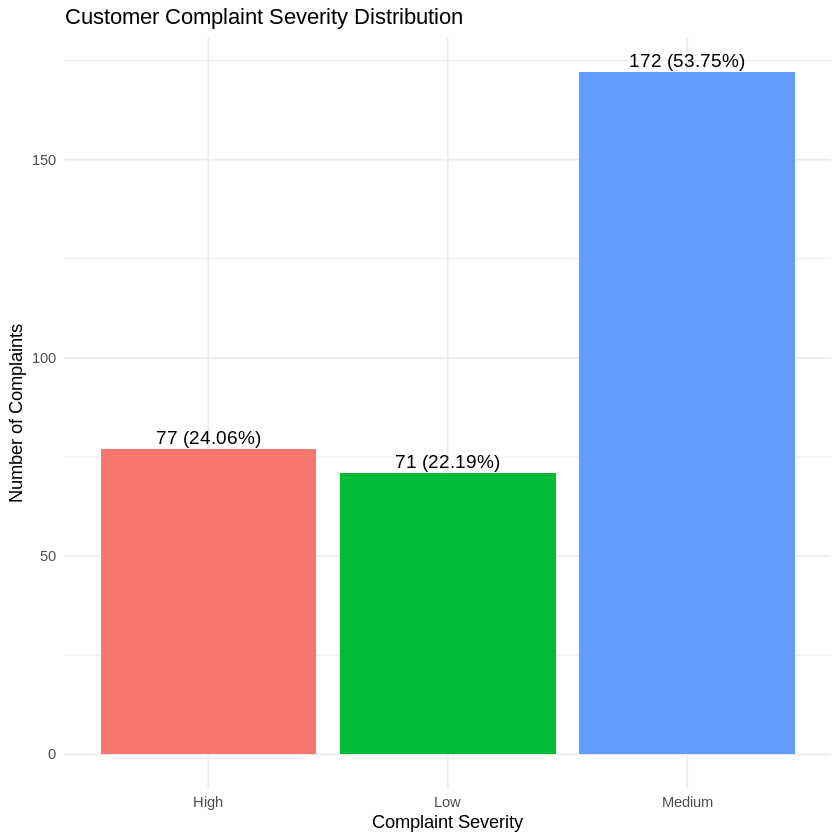

In [6]:
# Bar chart of complaint severity distribution
ggplot(complaint_severity_summary, aes(x = severity, y = n, fill = severity)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = paste0(n, " (", percentage, "%)")), vjust = -0.4, size = 4) +
  labs(
    title = "Customer Complaint Severity Distribution",
    x = "Complaint Severity",
    y = "Number of Complaints"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

In [ ]:
## 5. Driver Rating Distribution Analysis

A histogram is used to examine the distribution of driver ratings. This helps identify whether most drivers are performing consistently or whether a group of lower-rated drivers may require targeted review and support.

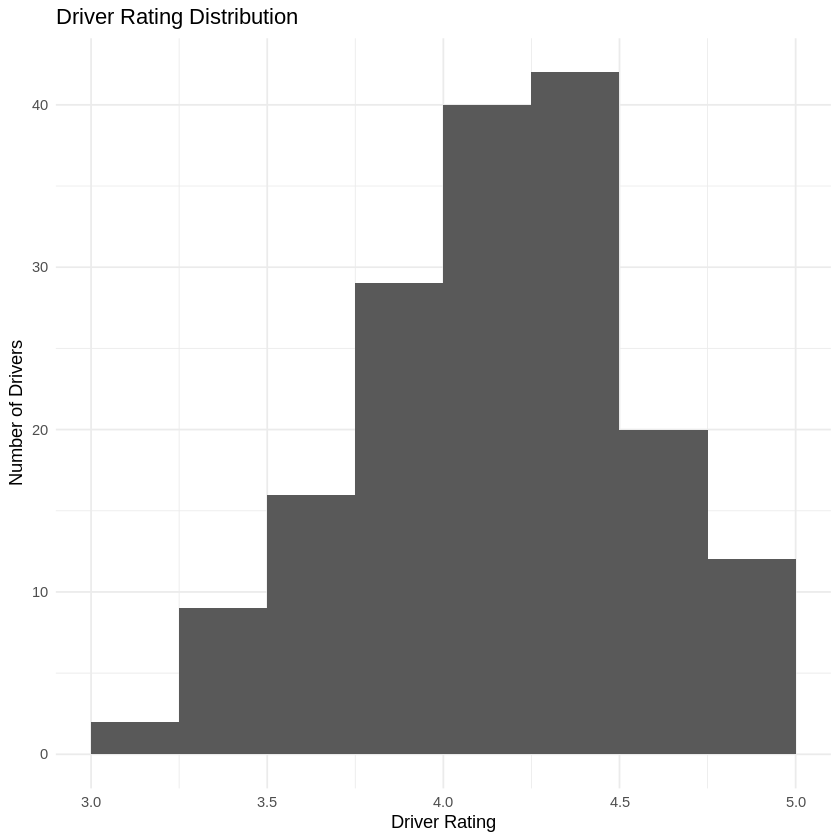

In [7]:
# Histogram of driver ratings
ggplot(drivers, aes(x = driver_rating)) +
  geom_histogram(binwidth = 0.25, boundary = 0) +
  labs(
    title = "Driver Rating Distribution",
    x = "Driver Rating",
    y = "Number of Drivers"
  ) +
  theme_minimal()

## 6. Operational Cost Distribution Analysis

A boxplot is used to examine the distribution of fuel or charging costs across deliveries. This helps identify variation in operational cost and whether unusually expensive delivery records are present.

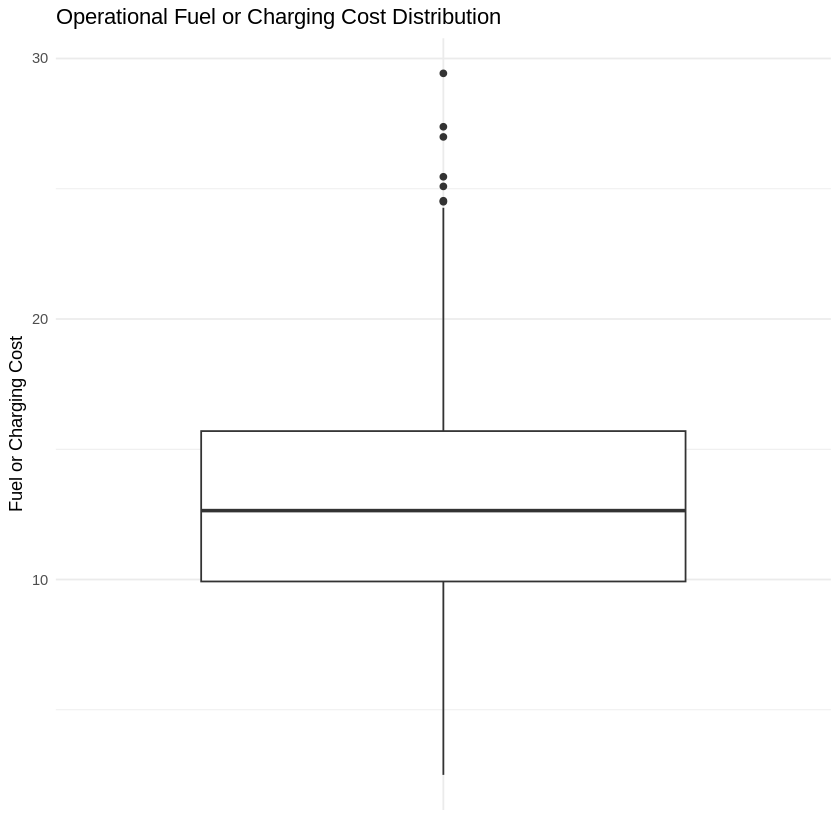

In [9]:
# Boxplot of operational fuel or charging costs
ggplot(deliveries, aes(x = "", y = fuel_or_charge_cost)) +
  geom_boxplot() +
  labs(
    title = "Operational Fuel or Charging Cost Distribution",
    x = "",
    y = "Fuel or Charging Cost"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_blank(),
        axis.ticks.x = element_blank())

## 7. Customer Type Distribution Analysis

A bar chart is used to examine the distribution of customer categories within the NorthStar dataset. This helps identify the main customer segments served by the organisation and provides context for later complaint analysis.


In [10]:
# Customer type distribution summary
customer_type_summary <- customers %>%
  count(customer_type) %>%
  mutate(percentage = round(n / sum(n) * 100, 2))

customer_type_summary

customer_type,n,percentage
<chr>,<int>,<dbl>
Consumer,476,73.23
Enterprise,50,7.69
SME,124,19.08


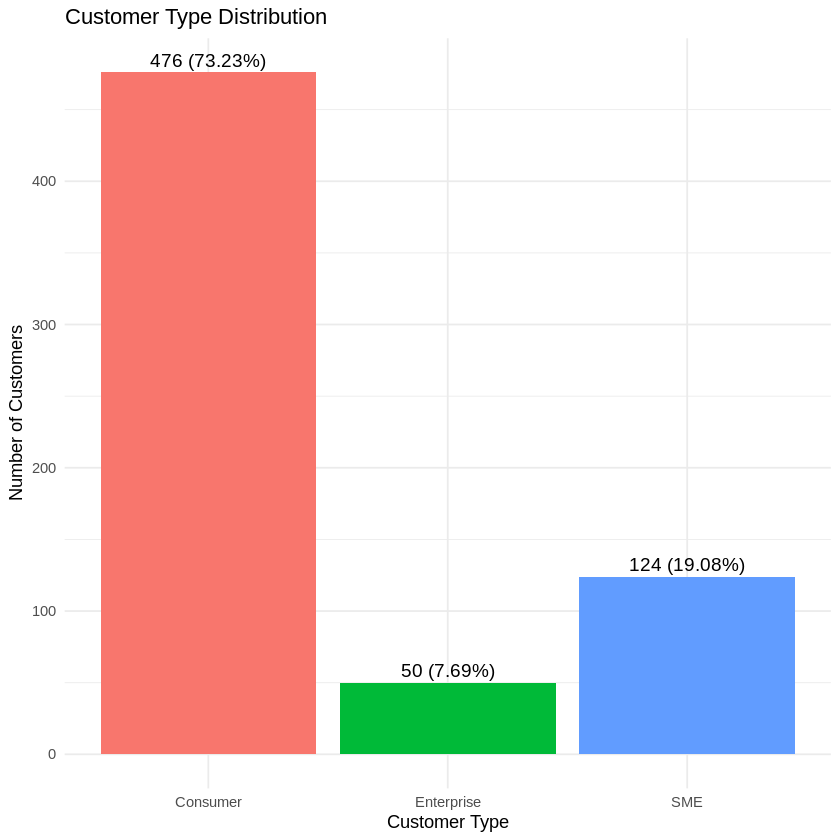

In [11]:
# Bar chart of customer type distribution
ggplot(customer_type_summary, aes(x = customer_type, y = n, fill = customer_type)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = paste0(n, " (", percentage, "%)")), vjust = -0.4, size = 4) +
  labs(
    title = "Customer Type Distribution",
    x = "Customer Type",
    y = "Number of Customers"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

## 8. Correlation Analysis

Correlation analysis is used to examine relationships between key numerical delivery variables, including route distance, manual route overrides, customer ratings, and operational costs. This helps identify which operational factors move together and may contribute to inefficiency.

In [12]:
# Select numerical delivery variables for correlation analysis
correlation_data <- deliveries %>%
  select(
    route_distance_km,
    manual_route_override_count,
    proof_of_completion_missing,
    customer_rating_post_delivery,
    fuel_or_charge_cost
  )

# Calculate correlation matrix using complete observations
correlation_matrix <- round(cor(correlation_data, use = "complete.obs"), 2)

correlation_matrix

,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
route_distance_km,1.00,0.20,0.02,0.03,0.53
manual_route_override_count,0.20,1.00,0.04,-0.06,0.10
proof_of_completion_missing,0.02,0.04,1.00,-0.22,0.06
customer_rating_post_delivery,0.03,-0.06,-0.22,1.00,-0.06
fuel_or_charge_cost,0.53,0.10,0.06,-0.06,1.00


## 9. Correlation Heatmap Visualisation

A correlation heatmap is created to visually represent the strength and direction of relationships between key delivery variables. This makes the statistical relationships easier to interpret and supports identification of operational cost and service-quality drivers.

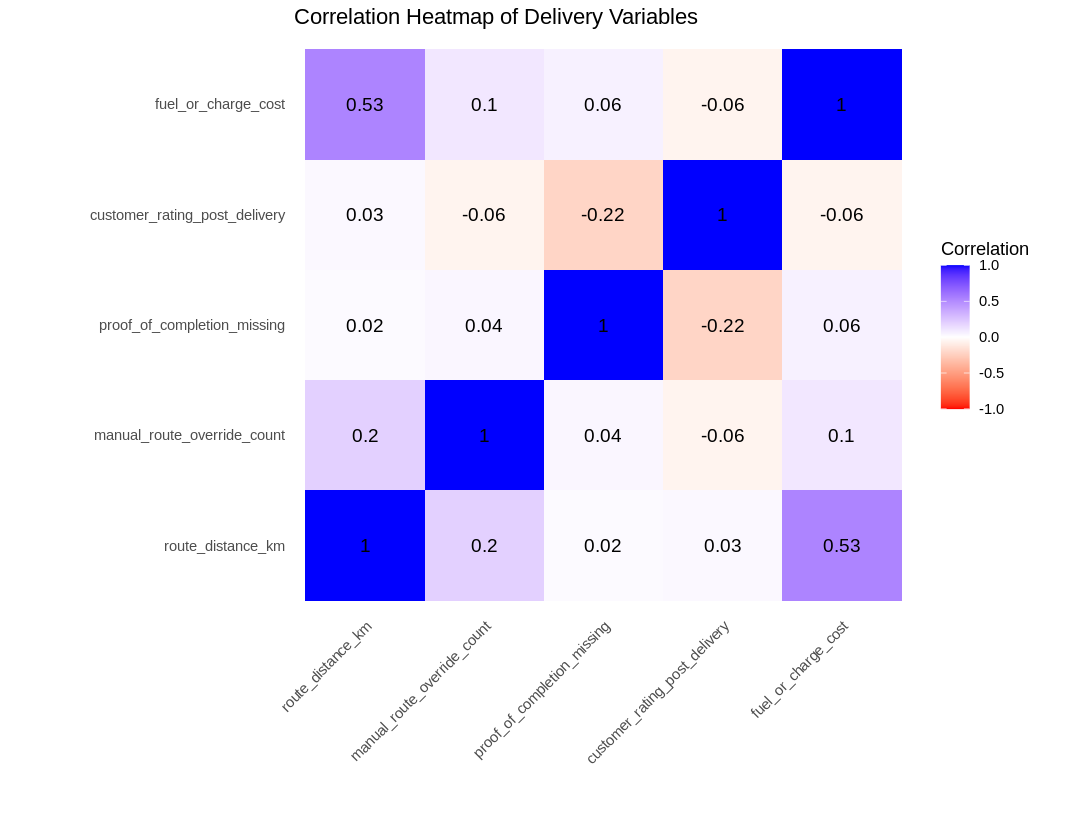

In [15]:
# Create a clearer correlation heatmap using ggplot2
correlation_df <- as.data.frame(as.table(correlation_matrix))
colnames(correlation_df) <- c("Variable_1", "Variable_2", "Correlation")

ggplot(correlation_df, aes(x = Variable_1, y = Variable_2, fill = Correlation)) +
  geom_tile() +
  geom_text(aes(label = Correlation), size = 4) +
  scale_fill_gradient2(
    low = "red",
    mid = "white",
    high = "blue",
    midpoint = 0,
    limits = c(-1, 1)
  ) +
  labs(
    title = "Correlation Heatmap of Delivery Variables",
    x = "",
    y = ""
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid = element_blank()
  )

## 10. Average Delivery Cost by Hub

A bar chart is created to compare average operational cost across delivery hubs. This helps identify whether specific locations are associated with higher delivery costs and may require operational review.

In [16]:
# Calculate average operational cost by hub
hub_cost_summary <- deliveries %>%
  group_by(hub_id) %>%
  summarise(
    average_operational_cost = round(mean(fuel_or_charge_cost, na.rm = TRUE), 2),
    total_deliveries = n()
  ) %>%
  left_join(hubs %>% select(hub_id, hub_name), by = "hub_id") %>%
  arrange(desc(average_operational_cost))

hub_cost_summary

hub_id,average_operational_cost,total_deliveries,hub_name
<chr>,<dbl>,<int>,<chr>
H05,13.69,115,Central Core
H06,13.32,104,Airport Hub
H04,13.17,127,West Gate
H07,12.92,115,Riverside Hub
H01,12.76,136,North Exchange
H03,12.74,119,East Dock
H02,12.56,106,South Link
H08,11.71,128,Midtown Relay


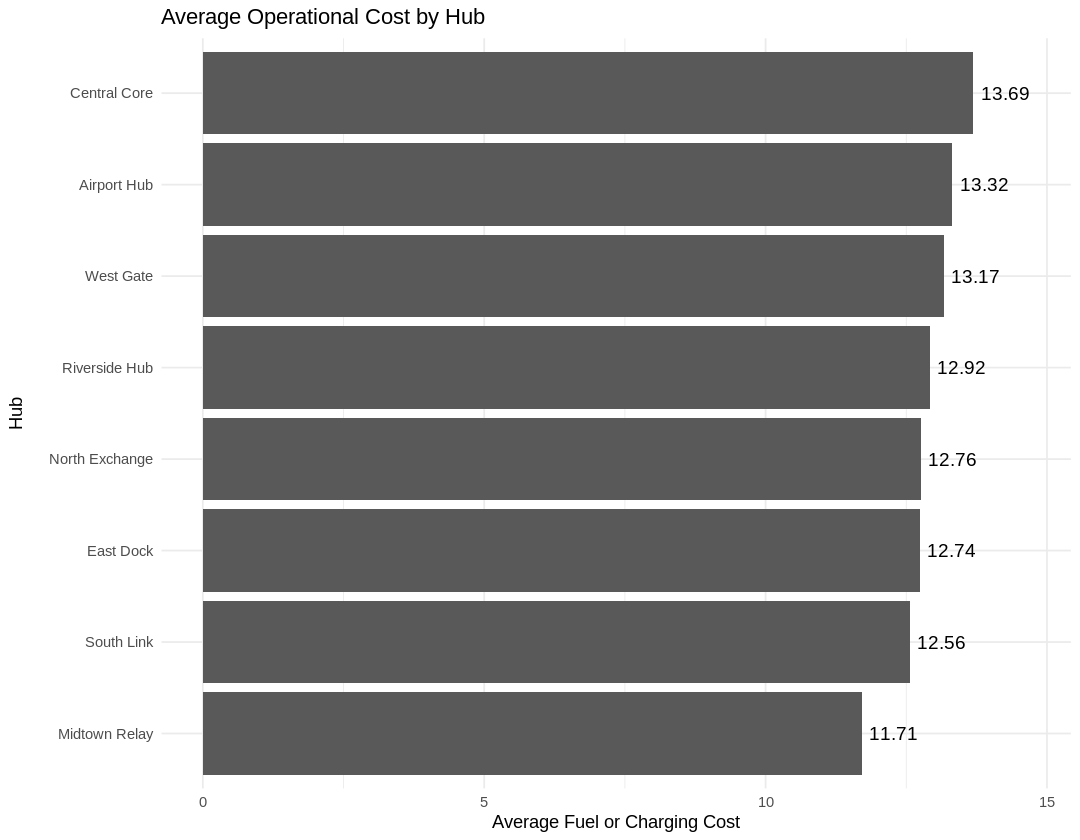

In [19]:
# Bar chart of average operational cost by hub
ggplot(hub_cost_summary, aes(x = reorder(hub_name, average_operational_cost),
                             y = average_operational_cost)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = average_operational_cost), hjust = -0.15, size = 4) +
  coord_flip() +
  expand_limits(y = max(hub_cost_summary$average_operational_cost) + 1) +
  labs(
    title = "Average Operational Cost by Hub",
    x = "Hub",
    y = "Average Fuel or Charging Cost"
  ) +
  theme_minimal()

## 11. Summary Statistics Analysis

Summary statistics are generated for key numerical variables to provide an overall view of delivery performance, customer behaviour, and complaint outcomes. This supports exploratory analysis by showing central tendency, spread, and range within the operational data.

In [20]:
# Summary statistics for key datasets
summary(deliveries[, c(
  "route_distance_km",
  "manual_route_override_count",
  "customer_rating_post_delivery",
  "fuel_or_charge_cost"
)])

summary(customers[, c(
  "age",
  "loyalty_score",
  "app_engagement_score"
)])

summary(complaints[, c(
  "resolution_days",
  "compensation_amount"
)])

 route_distance_km manual_route_override_count customer_rating_post_delivery
 Min.   : 1.200    Min.   :0.0000              Min.   :1.000                
 1st Qu.: 9.135    1st Qu.:0.0000              1st Qu.:3.360                
 Median :12.840    Median :1.0000              Median :4.040                
 Mean   :13.909    Mean   :0.9695              Mean   :3.865                
 3rd Qu.:16.835    3rd Qu.:2.0000              3rd Qu.:4.550                
 Max.   :41.940    Max.   :7.0000              Max.   :5.000                
                                               NAs    :14                   
 fuel_or_charge_cost
 Min.   : 2.500     
 1st Qu.: 9.925     
 Median :12.645     
 Mean   :12.841     
 3rd Qu.:15.697     
 Max.   :29.430     
                    

      age        loyalty_score   app_engagement_score
 Min.   :18.00   Min.   :13.10   Min.   :  1.00      
 1st Qu.:32.00   1st Qu.:49.00   1st Qu.: 45.38      
 Median :46.00   Median :59.60   Median : 59.00      
 Mean   :46.74   Mean   :59.69   Mean   : 58.13      
 3rd Qu.:62.00   3rd Qu.:70.45   3rd Qu.: 72.00      
 Max.   :78.00   Max.   :99.00   Max.   :100.00      
                 NAs    :20                          

 resolution_days  compensation_amount
 Min.   : 1.000   Min.   : 0.000     
 1st Qu.: 3.750   1st Qu.: 8.822     
 Median : 7.000   Median :18.405     
 Mean   : 7.928   Mean   :20.257     
 3rd Qu.:11.000   3rd Qu.:29.145     
 Max.   :25.000   Max.   :61.850     
                  NAs    :16         

## 12. Summary of R Analytics and Visualisation

The R analytics and visualisation workflow successfully identified several important operational patterns within the NorthStar dataset.

The analysis showed that 64.84% of deliveries were on time, while 21.26% were delayed and 13.89% failed. Route override analysis indicated a positive relationship between manual route changes and longer delivery distances, suggesting that routing inefficiencies may contribute to operational problems. Complaint analysis showed that medium-severity complaints were the most common category, although high-severity complaints still represented 24.06% of all complaint records.

The driver rating distribution showed that most drivers were rated within the moderate-to-high range, but lower-rated drivers were still present. Cost analysis identified several high-cost delivery outliers, while hub-level comparison showed that Central Core and Airport Hub recorded the highest average operational costs. Correlation analysis found the strongest relationship between route distance and fuel or charging cost, with a correlation of 0.53, and also showed a negative relationship between missing proof of completion and customer ratings.

Overall, the R analytics section demonstrated the value of statistical analysis and visualisation for identifying delivery inefficiencies, cost variation, customer-service issues, and relationships between operational variables within NorthStar.